<a href="https://colab.research.google.com/github/trisha123789/road_damage_safety/blob/main/road_damage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import kagglehub

In [19]:
from kagglehub import KaggleDatasetAdapter

In [20]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Path to dataset files: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes


In [21]:
path

'/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes'

In [22]:
import tensorflow as tf

In [23]:
from tensorflow.keras import layers,models

In [24]:
import os
dataset_path = os.path.join(path, "data", "images")
classes = os.listdir(dataset_path)
print(classes)
print("No.of classes:",len(classes))

['vlcsnap-2025-02-19-15h10m43s692.jpg', 'vlcsnap-2025-02-18-23h30m34s296.jpg', 'vlcsnap-2025-02-19-14h12m25s165.jpg', 'vlcsnap-2025-02-19-15h11m08s180.jpg', 'vlcsnap-2025-02-18-23h15m30s977.jpg', 'vlcsnap-2025-02-18-23h15m32s531.jpg', 'vlcsnap-2025-02-18-23h26m42s214.jpg', 'vlcsnap-2025-02-18-18h42m45s663.jpg', 'vlcsnap-2025-02-18-23h16m46s019.jpg', 'vlcsnap-2025-02-18-23h10m48s405.jpg', 'vlcsnap-2025-02-18-23h30m23s092.jpg', 'vlcsnap-2025-02-19-14h19m16s367.jpg', 'vlcsnap-00002.jpg', 'vlcsnap-2025-02-18-18h33m02s295.jpg', 'vlcsnap-2025-02-18-23h14m22s569.jpg', 'vlcsnap-2025-02-26-20h32m21s935.jpg', 'vlcsnap-2025-02-19-14h13m54s102.jpg', 'vlcsnap-2025-02-19-14h27m35s786.jpg', 'vlcsnap-00205.jpg', 'vlcsnap-2025-02-18-17h10m43s359.jpg', 'vlcsnap-00165.jpg', 'vlcsnap-2025-02-18-18h44m37s483.jpg', 'vlcsnap-00036.jpg', 'vlcsnap-00198.jpg', 'vlcsnap-2025-02-19-17h03m28s017.jpg', 'vlcsnap-2025-02-18-18h42m42s550.jpg', 'vlcsnap-2025-02-19-14h07m10s853.jpg', 'vlcsnap-2025-02-19-14h04m04s152.jpg

In [25]:
for item in os.listdir(dataset_path):
    print(item)

vlcsnap-2025-02-19-15h10m43s692.jpg
vlcsnap-2025-02-18-23h30m34s296.jpg
vlcsnap-2025-02-19-14h12m25s165.jpg
vlcsnap-2025-02-19-15h11m08s180.jpg
vlcsnap-2025-02-18-23h15m30s977.jpg
vlcsnap-2025-02-18-23h15m32s531.jpg
vlcsnap-2025-02-18-23h26m42s214.jpg
vlcsnap-2025-02-18-18h42m45s663.jpg
vlcsnap-2025-02-18-23h16m46s019.jpg
vlcsnap-2025-02-18-23h10m48s405.jpg
vlcsnap-2025-02-18-23h30m23s092.jpg
vlcsnap-2025-02-19-14h19m16s367.jpg
vlcsnap-00002.jpg
vlcsnap-2025-02-18-18h33m02s295.jpg
vlcsnap-2025-02-18-23h14m22s569.jpg
vlcsnap-2025-02-26-20h32m21s935.jpg
vlcsnap-2025-02-19-14h13m54s102.jpg
vlcsnap-2025-02-19-14h27m35s786.jpg
vlcsnap-00205.jpg
vlcsnap-2025-02-18-17h10m43s359.jpg
vlcsnap-00165.jpg
vlcsnap-2025-02-18-18h44m37s483.jpg
vlcsnap-00036.jpg
vlcsnap-00198.jpg
vlcsnap-2025-02-19-17h03m28s017.jpg
vlcsnap-2025-02-18-18h42m42s550.jpg
vlcsnap-2025-02-19-14h07m10s853.jpg
vlcsnap-2025-02-19-14h04m04s152.jpg
vlcsnap-00006.jpg
vlcsnap-2025-02-26-20h33m27s497.jpg
vlcsnap-2025-02-19-13h55m47s

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [27]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    brightness_range=[0.8,1.2],

    validation_split=0.2
)

In [28]:
train_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(128,128),

    batch_size=32,

    class_mode='categorical',

    subset='training'
)

Found 0 images belonging to 0 classes.


In [29]:
val_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(128,128),

    batch_size=32,

    class_mode='categorical',

    subset='validation'
)

Found 0 images belonging to 0 classes.


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model = Sequential()

In [31]:
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

model.add(MaxPooling2D((2,2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D((2,2)))

In [33]:
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D((2,2)))

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Dataset downloaded at:
/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes

Top-Level Files/Folders:

data

Images Path: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/images
Labels Path: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/labels

Total Label Files: 2009

Dataset Loaded Successfully
Images Shape: (2009, 128, 128, 3)
Labels Shape: (2009,)

TASK 1 — DATASET UNDERSTANDING

Classes:
['crack' 'manhole' 'pothole']

Number of Classes: 3

Image Dimensions:
(128, 128, 3)

Class Distribution:
crack      1002
manhole     541
pothole     466
Name: count, dtype: int64


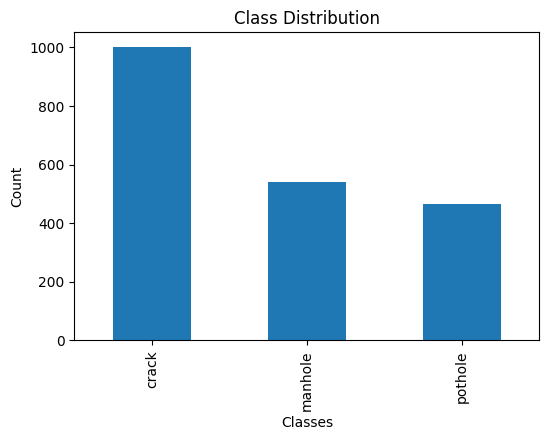

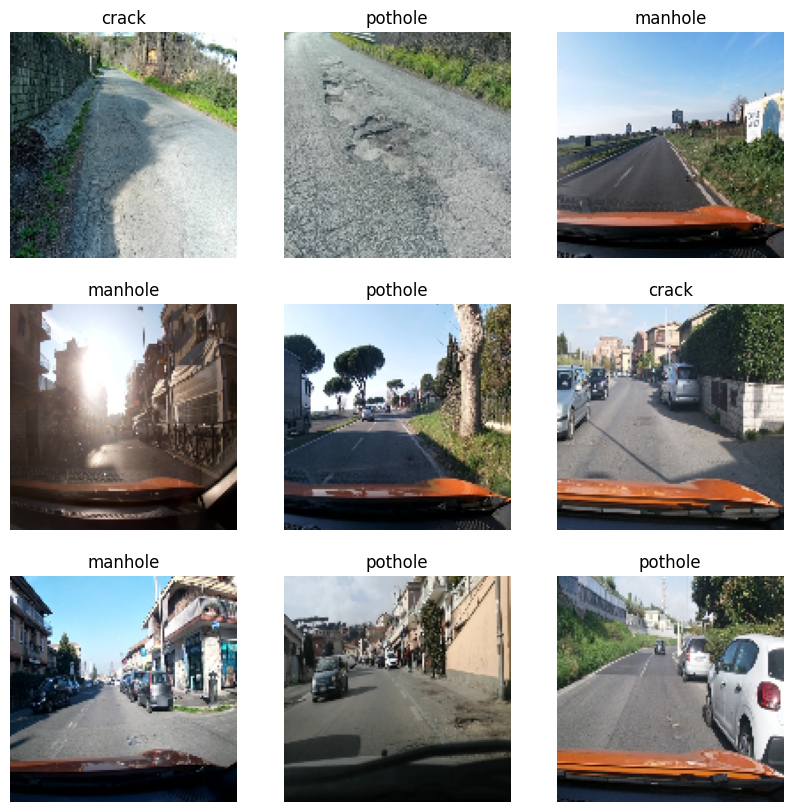


TASK 2 — PREPROCESSING

Encoded Labels:
[0 1 2]

Train Shape: (1607, 128, 128, 3)
Test Shape: (402, 128, 128, 3)

TASK 3 — DATA AUGMENTATION


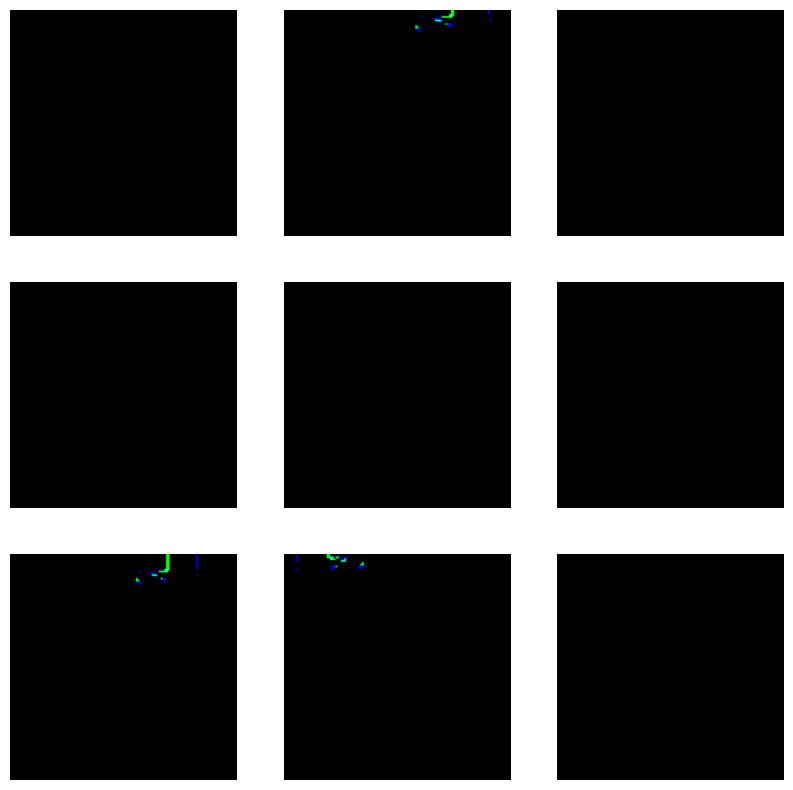


TASK 4 — CNN MODEL


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,923 (12.61 MB)

 Trainable params: 3,305,475 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)


TASK 5 — TRAINING
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 253ms/step - accuracy: 0.3889 - loss: 5.3690 - val_accuracy: 0.5000 - val_loss: 7.5062
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.4312 - loss: 2.5236 - val_accuracy: 0.5000 - val_loss: 16.6636
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.4810 - loss: 1.5507 - val_accuracy: 0.5000 - val_loss: 18.1919
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.4904 - loss: 1.2623 - val_accuracy: 0.5000 - val_loss: 23.0855
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.4953 - loss: 1.2185 - val_accuracy: 0.5000 - val_loss: 28.1149
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.4997 - loss: 1.2125 - val_accuracy: 0.5000 - val_loss: 38.1562
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.4972 - loss: 1.1072 - val_accuracy: 0.5000 - val_loss: 36.2468
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.4960 - los

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

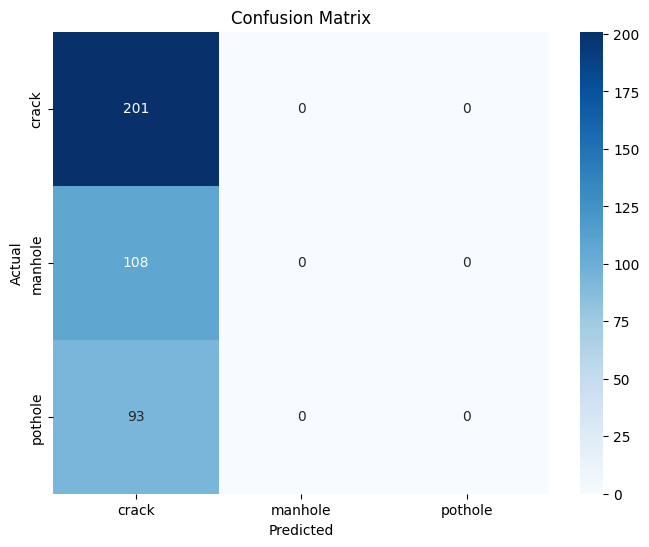


TASK 7 — ERROR ANALYSIS

Wrong Predictions: 201


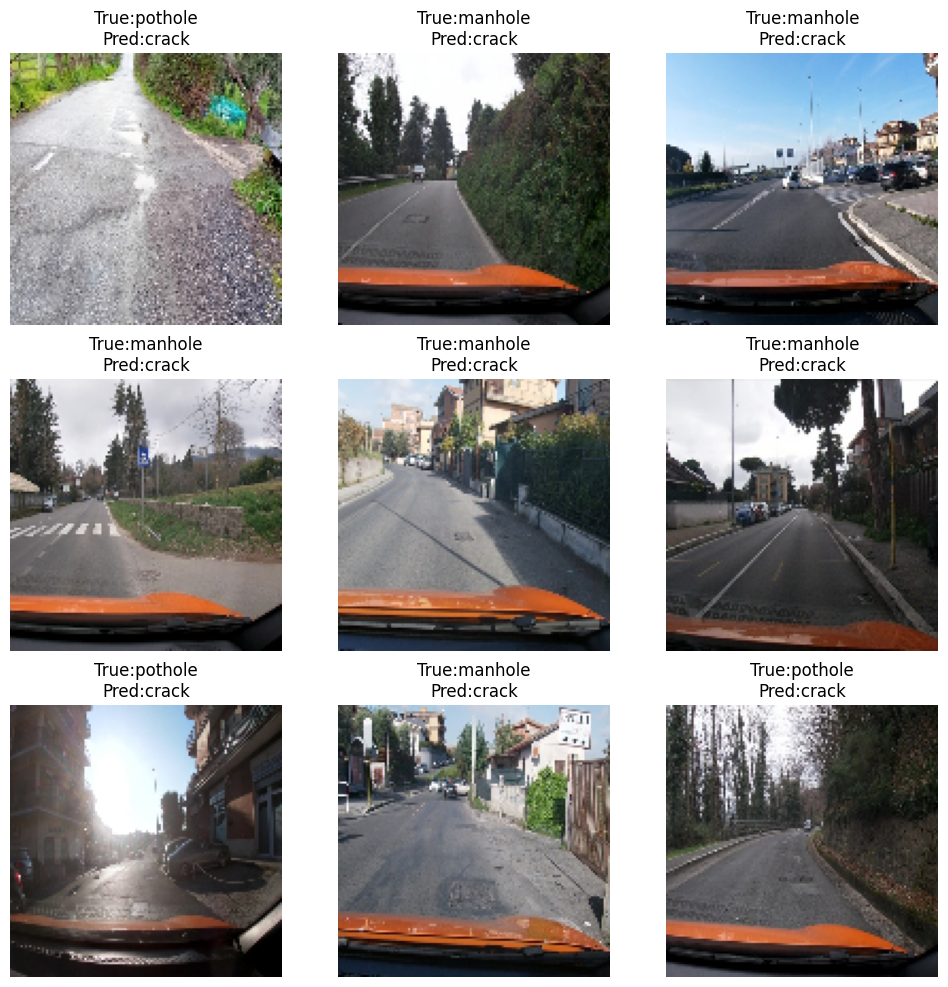


Possible Reasons for Misclassification:

1. Similar road textures
2. Poor lighting
3. Blurry images
4. Small potholes/cracks
5. Shadows and occlusion
6. Class imbalance


TASK 8 — REAL-TIME PREDICTION

TASK 9 — SAVE MODEL

Model saved successfully


ValueError: The filename must end in `.weights.h5`. Received: filepath=road_damage_weights.h5

In [36]:
# ============================================================
# ROAD DAMAGE DETECTION USING CNN
# COMPLETE END-TO-END PROJECT
# ============================================================

# ============================================================
# STEP 1 — INSTALL REQUIRED LIBRARIES
# ============================================================

# pip install kagglehub tensorflow opencv-python matplotlib
# pip install seaborn scikit-learn pandas pillow

# ============================================================
# STEP 2 — IMPORT LIBRARIES
# ============================================================

import os
import cv2
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

import kagglehub

# ============================================================
# STEP 3 — DOWNLOAD DATASET
# ============================================================

path = kagglehub.dataset_download(
    "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"
)

print("Dataset downloaded at:")
print(path)

# ============================================================
# STEP 4 — UNDERSTAND DATASET STRUCTURE
# ============================================================

print("\nTop-Level Files/Folders:\n")

for item in os.listdir(path):
    print(item)

# ============================================================
# IMPORTANT
# ============================================================
# This dataset is YOLO annotated.
# We will convert it into an IMAGE CLASSIFICATION dataset.
#
# We will:
# 1. Read image labels
# 2. Assign image-level class
# 3. Train CNN classifier
# ============================================================

# ============================================================
# STEP 5 — DEFINE PATHS
# ============================================================

images_path = os.path.join(path, "data", "images")
labels_path = os.path.join(path, "data", "labels")

print("\nImages Path:", images_path)
print("Labels Path:", labels_path)

# ============================================================
# STEP 6 — LOAD IMAGES + LABELS
# ============================================================

IMG_SIZE = 128

X = []
y = []

# YOLO CLASS MAP
# MODIFY IF DATASET HAS DIFFERENT LABELS

class_map = {
    0: "pothole",
    1: "crack",
    2: "manhole"
}

# ============================================================
# READ LABEL FILES
# ============================================================

label_files = os.listdir(labels_path)

print("\nTotal Label Files:", len(label_files))

# ============================================================
# PROCESS DATASET
# ============================================================

for label_file in label_files:

    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(labels_path, label_file)

    # Corresponding image
    image_name = label_file.replace(".txt", ".jpg")
    image_path = os.path.join(images_path, image_name)

    # Skip if image missing
    if not os.path.exists(image_path):
        continue

    # Read label
    with open(label_path, "r") as f:

        lines = f.readlines()

    # Skip empty labels
    if len(lines) == 0:
        continue

    # Use first object class
    first_line = lines[0].split()

    class_id = int(first_line[0])

    # Skip unknown class
    if class_id not in class_map:
        continue

    label = class_map[class_id]

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        continue

    # Convert BGR -> RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Normalize
    image = image / 255.0

    X.append(image)
    y.append(label)

# ============================================================
# CONVERT TO NUMPY
# ============================================================

X = np.array(X)
y = np.array(y)

print("\nDataset Loaded Successfully")
print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

# ============================================================
# TASK 1 — DATASET UNDERSTANDING
# ============================================================

print("\n==============================")
print("TASK 1 — DATASET UNDERSTANDING")
print("==============================")

# Number of classes
unique_classes = np.unique(y)

print("\nClasses:")
print(unique_classes)

print("\nNumber of Classes:", len(unique_classes))

# Image dimensions
print("\nImage Dimensions:")
print(X[0].shape)

# ============================================================
# CLASS IMBALANCE
# ============================================================

class_counts = pd.Series(y).value_counts()

print("\nClass Distribution:")
print(class_counts)

# Plot imbalance
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

# ============================================================
# SHOW SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(10,10))

for i in range(9):

    index = random.randint(0, len(X)-1)

    plt.subplot(3,3,i+1)

    plt.imshow(X[index])

    plt.title(y[index])

    plt.axis("off")

plt.show()

# ============================================================
# TASK 2 — DATA PREPROCESSING
# ============================================================

print("\n==============================")
print("TASK 2 — PREPROCESSING")
print("==============================")

# Label Encoding
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("\nEncoded Labels:")
print(np.unique(y_encoded))

# One Hot Encoding
y_categorical = to_categorical(y_encoded)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_categorical,

    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ============================================================
# TASK 3 — DATA AUGMENTATION
# ============================================================

print("\n==============================")
print("TASK 3 — DATA AUGMENTATION")
print("==============================")

# WHY AUGMENTATION?
#
# Helps model generalize better by simulating:
# - different lighting
# - different camera angles
# - real-world conditions
#
# Prevents overfitting.
#

train_datagen = ImageDataGenerator(

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    brightness_range=[0.8, 1.2]
)

train_generator = train_datagen.flow(

    X_train,
    y_train,

    batch_size=32
)

# ============================================================
# SHOW AUGMENTED IMAGES
# ============================================================

sample_image = X_train[0].reshape((1, IMG_SIZE, IMG_SIZE, 3))

aug_iter = train_datagen.flow(sample_image, batch_size=1)

plt.figure(figsize=(10,10))

for i in range(9):

    augmented = next(aug_iter)[0]

    plt.subplot(3,3,i+1)

    plt.imshow(augmented)

    plt.axis("off")

plt.show()

# ============================================================
# TASK 4 — CNN ARCHITECTURE
# ============================================================

print("\n==============================")
print("TASK 4 — CNN MODEL")
print("==============================")

model = Sequential()

# ============================================================
# CNN BLOCK 1
# ============================================================

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# ============================================================
# CNN BLOCK 2
# ============================================================

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# ============================================================
# CNN BLOCK 3
# ============================================================

model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# ============================================================
# FLATTEN
# ============================================================

model.add(Flatten())

# ============================================================
# DENSE LAYERS
# ============================================================

model.add(Dense(128, activation='relu'))

# Dropout prevents overfitting
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    len(unique_classes),
    activation='softmax'
))

# ============================================================
# MODEL SUMMARY
# ============================================================

model.summary()

# ============================================================
# TASK 5 — MODEL TRAINING
# ============================================================

print("\n==============================")
print("TASK 5 — TRAINING")
print("==============================")

model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

history = model.fit(

    train_generator,

    validation_data=(X_test, y_test),

    epochs=15
)

# ============================================================
# TASK 6 — MODEL EVALUATION
# ============================================================

print("\n==============================")
print("TASK 6 — EVALUATION")
print("==============================")

# Predictions
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

# Accuracy
accuracy = accuracy_score(
    true_classes,
    predicted_classes
)

print("\nAccuracy:", accuracy)

# Precision
precision = precision_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

print("Precision:", precision)

# Recall
recall = recall_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

print("Recall:", recall)

# F1 Score
f1 = f1_score(
    true_classes,
    predicted_classes,
    average='weighted'
)

print("F1 Score:", f1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(classification_report(

    true_classes,
    predicted_classes,

    target_names=encoder.classes_
))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',

    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# TASK 7 — ERROR ANALYSIS
# ============================================================

print("\n==============================")
print("TASK 7 — ERROR ANALYSIS")
print("==============================")

wrong_indices = np.where(
    predicted_classes != true_classes
)[0]

print("\nWrong Predictions:", len(wrong_indices))

# Show wrong predictions
plt.figure(figsize=(12,12))

for i, idx in enumerate(wrong_indices[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[idx])

    true_label = encoder.inverse_transform(
        [true_classes[idx]]
    )[0]

    pred_label = encoder.inverse_transform(
        [predicted_classes[idx]]
    )[0]

    plt.title(f"True:{true_label}\nPred:{pred_label}")

    plt.axis("off")

plt.show()

# ============================================================
# POSSIBLE REASONS FOR FAILURE
# ============================================================

print("""
Possible Reasons for Misclassification:

1. Similar road textures
2. Poor lighting
3. Blurry images
4. Small potholes/cracks
5. Shadows and occlusion
6. Class imbalance
""")

# ============================================================
# TASK 8 — REAL-TIME PREDICTION
# ============================================================

print("\n==============================")
print("TASK 8 — REAL-TIME PREDICTION")
print("==============================")

def predict_image(image_path):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    image = image / 255.0

    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)

    predicted_index = np.argmax(prediction)

    label = encoder.inverse_transform(
        [predicted_index]
    )[0]

    confidence = np.max(prediction)

    plt.imshow(image[0])

    plt.title(
        f"Prediction: {label}\nConfidence:{confidence:.2f}"
    )

    plt.axis("off")

    plt.show()

# ============================================================
# TEST WITH IMAGE
# ============================================================

# predict_image("test.jpg")

# ============================================================
# TASK 9 — SAVE MODEL
# ============================================================

print("\n==============================")
print("TASK 9 — SAVE MODEL")
print("==============================")

# Save complete model
model.save("road_damage_model.h5")

print("\nModel saved successfully")

# Save weights
model.save_weights("road_damage_weights.h5")

print("Weights saved successfully")

# Save label mapping
label_mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
)

with open("label_mapping.json", "w") as f:

    json.dump(label_mapping, f)

print("Label mapping saved successfully")

# ============================================================
# LOAD MODEL LATER
# ============================================================

# from tensorflow.keras.models import load_model
#
# model = load_model("road_damage_model.h5")

# ============================================================
# PROJECT COMPLETED
# ============================================================

print("\nROAD DAMAGE CNN PROJECT COMPLETED SUCCESSFULLY")